In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [5]:
f = h5py.File("data/hubbard_tebd.hdf5", "r")
exact_energy = f["exact_energy"][()]
dmrg_bond_dims = f["dmrg_bond_dims"][:]
print(dmrg_bond_dims)
tebd_bond_dims = f["tebd_bond_dims"][:]
print(tebd_bond_dims)
dmrg_energies = f["dmrg_energies"][:]
tebd_energies = f["tebd_energies"][:, :]
energies_u = f["energies_u"][:]
f.close()

[ 5 10 20 30]
[ 5 10 20 30]


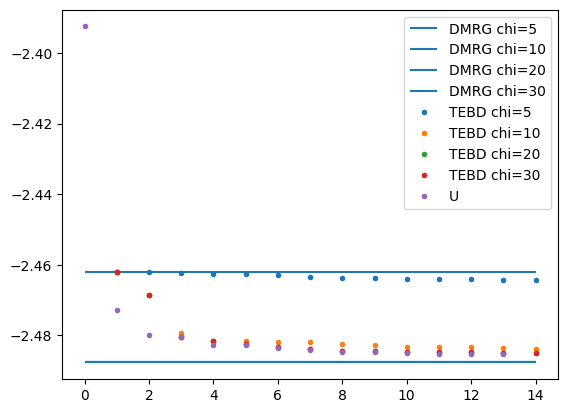

In [7]:
fig, ax = plt.subplots()

d_max = tebd_energies.shape[-1]

for chi, energy in zip(dmrg_bond_dims, dmrg_energies):
    ax.hlines(energy, 0., d_max, label=f"DMRG chi={chi}")

for i in range(len(tebd_bond_dims)):
    ax.plot(range(1, d_max+1), tebd_energies[i, :], '.', label=f"TEBD chi={tebd_bond_dims[i]}")

ax.plot(energies_u, '.', label="U")

plt.legend()

# ax.set_ylim(-2.6, -2.4)

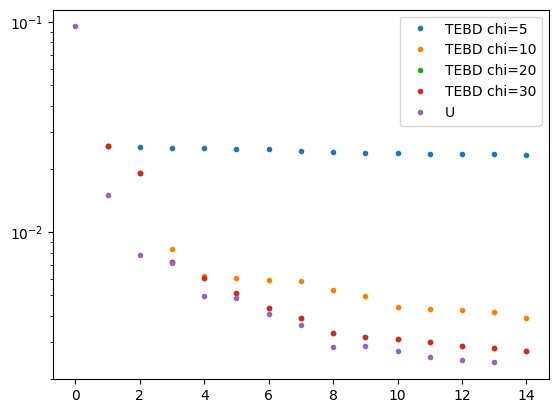

In [8]:
tebd_errs = np.abs(tebd_energies - exact_energy)
u_errs = np.abs(energies_u - exact_energy)

fig2, ax2 = plt.subplots()

for i in range(len(tebd_bond_dims)):
    ax2.plot(range(1, d_max+1), tebd_errs[i, :], '.', label=f"TEBD chi={tebd_bond_dims[i]}")
ax2.plot(u_errs, '.', label="U")

ax2.set_yscale('log')
plt.legend()